In [1]:
import numpy as np
import pandas as pd
from scipy import constants
import glob 
import matlab.engine
import matplotlib.pyplot as plt
from multiprocessing import Pool
import copy
from itertools import combinations

In [2]:
def svd_beamformer_analog(H):
    ant_tx, ant_rx = np.shape(H)
    u, s, wr_opt = np.linalg.svd(H)
    u, s, wt_opt = np.linalg.svd(np.transpose(H))
    
    wr_quant_angle = -np.transpose(np.around(np.angle(wr_opt)/(np.pi/2))*(np.pi/2))
    wt_quant_angle = -np.transpose(np.around(np.angle(wt_opt)/(np.pi/2))*(np.pi/2))
    
    wr_quant = np.exp(1j*wr_quant_angle)
    wt_quant = np.exp(1j*wt_quant_angle)
    
    rss = []
    beam_idx = []
    for i in range(ant_tx):
        for j in range(ant_rx):
            signal = np.abs(np.matmul(wt_quant[:,i],np.matmul(H,wr_quant[:,j])))**2
            rss.append(10*np.log10(signal*1000))
            beam_idx.append([i,j])
    
    idx = np.argmax(np.array(rss))
    tx_idx = beam_idx[idx][0]
    rx_idx = beam_idx[idx][1]
            
    wr_quant_out = wr_quant[:,rx_idx]
    wt_quant_out = wt_quant[:,tx_idx] 
    
    return wt_quant_out, wr_quant_out

In [3]:
eng = matlab.engine.start_matlab()

In [4]:
azi_files = sorted(glob.glob('./output_reduced_visibility_alt40/az*'))

In [5]:
radius = 6378100

tx = {'freq':11.325e9,
      'light_speed':constants.c,
      'power': 4.89e6,
      'num_ant': 1,
      'rf_chain':1,
      'ant_spacing':constants.c/11.325e9/2,
      'bandwidth':2000e6,
      'height':550e3,
      'speed':np.sqrt(5.9722e24 * 6.6743e-11 / (radius + 550e3))}

rx = {'freq':11.325e9,
      'light_speed':constants.c,
      'power': 1,
      'num_ant': 36,
      'rf_chain':1,
      'ant_spacing':constants.c/11.325e9/2,
      'height':0,
      'speed':0}

In [6]:
def normalize(x):
    x = x/np.sqrt(np.sum(np.abs(x)**2))
    return x

def normalize_row(x):
    x = x/np.sqrt(np.sum(np.abs(x)**2))
    for i in range(len(x)):
        x[i,:] = x[i,:]/np.sqrt(np.sum(np.abs(x[i,:])**2))
    return x

def kernel_function(azi_file, noise = -80, lock = 1):
    print("Now Processing " + azi_file)
    alt_file = azi_file.replace('az','alt')
    dist_file = azi_file.replace('az','distance')
    
    azi_data = pd.read_csv(azi_file)
    alt_data = pd.read_csv(alt_file)
    dist_data = pd.read_csv(dist_file)
    
    satellites = list(azi_data.columns)[2:]
    
    rss_ori = np.ones((len(azi_data),len(satellites)))*np.nan
    rss_beamformed = np.ones((len(azi_data),len(satellites)))*np.nan
    rate_ori = np.ones((len(azi_data),len(satellites)))*np.nan
    rate_beamformed = np.ones((len(azi_data),len(satellites)))*np.nan
    
    sinr_ori = []
    sinr_bf = []
    sinr_ori_nprecoding = []
    sinr_bf_nprecoding = []
    
    rate_ori_list = []
    rate_bf_list = []
    rate_ori_nprecoding_list = []
    rate_bf_nprecoding_list = []
    for timestamp in range(len(azi_data)):
        txang_azi = azi_data.iloc[timestamp,2:].values
        index = np.where(txang_azi!=0)[0]
        
        txang_azi = txang_azi[txang_azi!=0]-np.pi
        txang_ele = alt_data.iloc[timestamp,2:].values
        txang_ele = txang_ele[txang_ele!=0]
        txang = matlab.double(np.array([txang_azi,txang_ele]).tolist())
       
        rxang_azi = azi_data.iloc[timestamp,2:].values
        rxang_azi = rxang_azi[rxang_azi!=0]-np.pi
        rxang_ele = alt_data.iloc[timestamp,2:].values
        rxang_ele = rxang_ele[rxang_ele!=0]
        rxang = matlab.double(np.array([rxang_azi,rxang_ele]).tolist())
        
        dist = np.array(dist_data.iloc[timestamp,2:].values)*1000
        dist = matlab.double(dist[dist!=0].tolist())
        
        H = np.array(eng.get_channel_MUMIMO(matlab.double(tx["num_ant"]), matlab.double(rx["num_ant"]), 
                            matlab.double(tx["rf_chain"]), matlab.double(rx["rf_chain"]),
                           matlab.double(tx["freq"]), txang, rxang, dist, matlab.double(tx['speed']), matlab.double(rx['speed'])))
        
        rss_ori_cur = []
        rss_beamformed_cur = []
        rate_ori_cur = []
        rate_beamformed_cur = []
        rate_ori_nprecoding_cur = []
        rate_beamformed_nprecoding_cur = []
        interference_matrix_ori = np.zeros((len(index), len(index)), dtype = complex)
        interference_matrix_beamformed = np.zeros((len(index), len(index)),dtype = complex)
        for i in range(len(index)):
            wt, wr = np.squeeze(svd_beamformer_analog(H[i,i,:,:]))
            for j in range(len(index)):
                sig_ori_sat = np.sum(np.squeeze(H[i,j,:,:]))
                sig_beamformed_sat = np.squeeze(np.matmul(np.expand_dims(wt, axis = 0), np.matmul(H[i,j,:,:], np.expand_dims(wr, axis = 1))))

                interference_matrix_ori[i,j] = sig_ori_sat
                interference_matrix_beamformed[i,j] = sig_beamformed_sat
            
            sinr_ori_nprecoding_cur = tx['power']/tx['num_ant']*np.abs(interference_matrix_ori[i,i])**2/(tx['power']/tx['num_ant']*np.abs(np.sum(interference_matrix_ori[i,:]) - interference_matrix_ori[i,i])**2 + 1e-12)
            sinr_bf_nprecoding_cur = tx['power']/tx['num_ant']*np.abs(interference_matrix_beamformed[i,i])**2/(tx['power']/tx['num_ant']*np.abs(np.sum(interference_matrix_beamformed[i,:]) - interference_matrix_beamformed[i,i])**2 + 1e-12)
            # sinr_ori_nprecoding_cur =  tx['power']/tx['num_ant']*np.abs(interference_matrix_ori[i,i])**2/1e-12
            # sinr_bf_nprecoding_cur =  tx['power']/tx['num_ant']*np.abs(interference_matrix_beamformed[i,i])**2/1e-12
            sinr_ori_nprecoding.append(10*np.log10(sinr_ori_nprecoding_cur))
            sinr_bf_nprecoding.append(10*np.log10(sinr_bf_nprecoding_cur))
            
            rate_ori_nprecoding_cur.append(tx["bandwidth"]*np.log2(1+sinr_ori_nprecoding_cur))
            rate_beamformed_nprecoding_cur.append(tx["bandwidth"]*np.log2(1+sinr_bf_nprecoding_cur))
            
        rate_ori_nprecoding_list.append(np.sum(rate_ori_nprecoding_cur))
        rate_bf_nprecoding_list.append(np.sum(rate_beamformed_nprecoding_cur))
        
        # rate_ori_nprecoding_list.append(np.mean(rate_ori_nprecoding_cur))
        # rate_bf_nprecoding_list.append(np.max(rate_beamformed_nprecoding_cur))
        
        precoding_weight_ori = normalize(np.linalg.pinv(interference_matrix_ori))*np.sqrt(tx['power']/tx['num_ant'])
        precoding_weight_beamformed = normalize(np.linalg.pinv(interference_matrix_beamformed))*np.sqrt(tx['power']/tx['num_ant'])
        
        cancelled_channel_ori = np.matmul(interference_matrix_ori, precoding_weight_ori)
        cancelled_channel_beamformed = np.matmul(interference_matrix_beamformed, precoding_weight_beamformed)
        
        #print(cancelled_channel_ori)
        #print(dist)
        
        for i in range(len(index)):
            rss_ori_cur.append(10*np.log10(np.abs(cancelled_channel_ori[i,i])**2*1000))
            rss_beamformed_cur.append(10*np.log10(np.abs(cancelled_channel_beamformed[i,i])**2*1000))
            
            sinr_ori_cur = np.abs(cancelled_channel_ori[i,i])**2/(np.abs(np.sum(cancelled_channel_ori[i,:]) - cancelled_channel_ori[i,i])**2 + 1e-12)
            sinr_bf_cur = np.abs(cancelled_channel_beamformed[i,i])**2/(np.abs(np.sum(cancelled_channel_beamformed[i,:]) - cancelled_channel_beamformed[i,i])**2 + 1e-12)

            rate_ori_cur.append(tx["bandwidth"]*np.log2(1 + sinr_ori_cur))
            rate_beamformed_cur.append(tx["bandwidth"]*np.log2(1 + sinr_bf_cur))
            
            sinr_ori.append(10*np.log10(sinr_ori_cur))
            sinr_bf.append(10*np.log10(sinr_bf_cur))
            
        rate_ori_list.append(np.sum(rate_ori_cur))
        rate_bf_list.append(np.sum(rate_beamformed_cur))

        rss_ori[timestamp,index] = rss_ori_cur
        rss_beamformed[timestamp,index] = rss_beamformed_cur
        rate_ori[timestamp, index] = rate_ori_cur
        rate_beamformed[timestamp, index] = rate_beamformed_cur
        
        if np.mod(timestamp+1, 100) == 0 or timestamp+1 == len(azi_data):
            print("Processed " + alt_file + " " + str(timestamp+1) + "/" + str(len(azi_data)) + " timestamps")
    
    fout = azi_file.replace('az','rss_ori_MU-MIMO')
    df_out = pd.DataFrame(rss_ori.tolist(), columns = satellites)
    df_out.to_csv(fout)

    fout = azi_file.replace('az','rss_beamformed_MU-MIMO')
    df_out = pd.DataFrame(rss_beamformed.tolist(), columns = satellites)
    df_out.to_csv(fout)
    
    fout = azi_file.replace('az','rate_ori_MU-MIMO')
    df_out = pd.DataFrame(rate_ori.tolist(), columns = satellites)
    df_out.to_csv(fout)
    
    fout = azi_file.replace('az','rate_beamformed_MU-MIMO')
    df_out = pd.DataFrame(rate_beamformed.tolist(), columns = satellites)
    df_out.to_csv(fout)
    
    return sinr_ori, sinr_bf, sinr_ori_nprecoding, sinr_bf_nprecoding, rate_ori_list, rate_bf_list, rate_ori_nprecoding_list, rate_bf_nprecoding_list

In [7]:
def normalize(x):
    x = x/np.sqrt(np.sum(np.abs(x)**2))
    return x

def normalize_row(x):
    x = x/np.sqrt(np.sum(np.abs(x)**2))
    for i in range(len(x)):
        x[i,:] = x[i,:]/np.sqrt(np.sum(np.abs(x[i,:])**2))
    return x

def combs(num):
    x = list(range(num))
    return [c for i in range(len(x)+1) for c in combinations(x,i)]

def get_beamformed_rate(azi_file, timestamp, sat_selection):
    #print("Now Processing " + azi_file)
    alt_file = azi_file.replace('az','alt')
    dist_file = azi_file.replace('az','distance')
    
    azi_data = pd.read_csv(azi_file)
    alt_data = pd.read_csv(alt_file)
    dist_data = pd.read_csv(dist_file)
    
    satellites = list(azi_data.columns)[2:]
    
    ######################## start RF calculation#####################
    txang_azi = azi_data.iloc[timestamp,2:].values
    index = np.where(txang_azi!=0)[0]
    
    rate_beamformed_nprecoding = np.zeros(len(index), dtype = np.float64)
    rate_beamformed_FDMA_nprecoding = np.zeros(len(index), dtype = np.float64)
    rate_beamformed_precoding = np.zeros(len(index), dtype = np.float64)
    rate_beamformed_FDMA_precoding = np.zeros(len(index), dtype = np.float64)
    
    if len(sat_selection) > len(index):
        raise ValueError('number of selected satellite is larger than number of visible satellite')

    txang_azi = txang_azi[txang_azi!=0]-np.pi
    txang_ele = alt_data.iloc[timestamp,2:].values
    txang_ele = txang_ele[txang_ele!=0]
    txang = matlab.double(np.array([txang_azi,txang_ele]).tolist())

    rxang_azi = azi_data.iloc[timestamp,2:].values
    rxang_azi = rxang_azi[rxang_azi!=0]-np.pi
    rxang_ele = alt_data.iloc[timestamp,2:].values
    rxang_ele = rxang_ele[rxang_ele!=0]
    rxang = matlab.double(np.array([rxang_azi,rxang_ele]).tolist())

    dist = np.array(dist_data.iloc[timestamp,2:].values)*1000
    dist = matlab.double(dist[dist!=0].tolist())
    
    #################### get channel #######################
    H = np.array(eng.get_channel_MUMIMO(matlab.double(tx["num_ant"]), matlab.double(rx["num_ant"]), 
                        matlab.double(tx["rf_chain"]), matlab.double(rx["rf_chain"]),
                       matlab.double(tx["freq"]), txang, rxang, dist, matlab.double(tx['speed']), matlab.double(rx['speed'])))

    #################### calculate interference matrix ##########################
    interference_matrix_beamformed = np.zeros((len(index), len(index)),dtype = np.complex128)
    interference_matrix_beamformed_FDMA = np.zeros((len(index), len(index)),dtype = np.complex128)
    for i in range(len(index)):
        wt, wr = svd_beamformer_analog(H[i,i,:,:])
        for j in range(len(index)):
            sig_beamformed_sat = np.squeeze(np.matmul(np.expand_dims(wt, axis = 0), np.matmul(H[i,j,:,:], np.expand_dims(wr, axis = 1))))
            interference_matrix_beamformed[i,j] = sig_beamformed_sat
            if i in sat_selection and j in sat_selection:
                interference_matrix_beamformed_FDMA[i,j] = sig_beamformed_sat
        sinr_bf_nprecoding_cur = tx['power']/tx['num_ant']*np.abs(interference_matrix_beamformed[i,i])**2/(tx['power']/tx['num_ant']*np.abs(np.sum(interference_matrix_beamformed[i,:]) - interference_matrix_beamformed[i,i])**2 + 1e-12)
        rate_beamformed_nprecoding[i] = tx["bandwidth"]*np.log2(1+sinr_bf_nprecoding_cur)
    
    # FDMA channel
    for i in sat_selection:
        sinr_bf_nprecoding_FDMA_cur = tx['power']/tx['num_ant']*np.abs(interference_matrix_beamformed_FDMA[i,i])**2/(tx['power']/tx['num_ant']*np.abs(np.sum(interference_matrix_beamformed_FDMA[i,:]) - interference_matrix_beamformed_FDMA[i,i])**2 + 1e-12)
        rate_beamformed_FDMA_nprecoding[i] = tx["bandwidth"]*np.log2(1+sinr_bf_nprecoding_FDMA_cur)

    ###################### precoding ########################
    interference_matrix_beamformed_selected = np.zeros((len(sat_selection), len(sat_selection)),dtype = np.complex128)
    for sat_sub_id, sat_id in enumerate(sat_selection):
        interference_matrix_beamformed_selected[sat_sub_id, :] = interference_matrix_beamformed[sat_id, sat_selection]
    
    precoding_weight_selected = normalize_row(np.linalg.pinv(interference_matrix_beamformed_selected))*np.sqrt(tx['power']/tx['num_ant'])
    precoding_weight_beamformed = np.identity(len(index),dtype = np.complex128)*np.sqrt(tx['power']/tx['num_ant'])
    for sat_sub_id, sat_id in enumerate(sat_selection):
        precoding_weight_beamformed[sat_id, sat_selection] = precoding_weight_selected[sat_sub_id,:]
    
    cancelled_channel_beamformed = np.matmul(interference_matrix_beamformed, precoding_weight_beamformed)
    cancelled_channel_beamformed_FDMA = np.matmul(interference_matrix_beamformed_FDMA, precoding_weight_beamformed)

    for i in range(len(index)):
        sinr_bf_cur = np.abs(cancelled_channel_beamformed[i,i])**2/(np.abs(np.sum(cancelled_channel_beamformed[i,:]) - cancelled_channel_beamformed[i,i])**2 + 1e-12)
        rate_beamformed_precoding[i] = tx["bandwidth"]*np.log2(1 + sinr_bf_cur)
        
        sinr_bf_FDMA_cur = np.abs(cancelled_channel_beamformed_FDMA[i,i])**2/(np.abs(np.sum(cancelled_channel_beamformed_FDMA[i,:]) - cancelled_channel_beamformed_FDMA[i,i])**2 + 1e-12)
        rate_beamformed_FDMA_precoding[i] = tx["bandwidth"]*np.log2(1 + sinr_bf_FDMA_cur)

    return np.sum(rate_beamformed_nprecoding[sat_selection]), np.sum(rate_beamformed_FDMA_nprecoding[sat_selection]), np.sum(rate_beamformed_precoding[sat_selection]), np.sum(rate_beamformed_FDMA_precoding[sat_selection])

In [9]:
total = 0
count = 0
rate_beamformed_nprecoding_dict = {}
rate_beamformed_FDMA_nprecoding_dict = {}
rate_beamformed_precoding_dict = {}
rate_beamformed_FDMA_precoding_dict = {}
for file in [azi_files[0]]:
    for timestamp in range(900):
        total += 1
        if np.mod(timestamp + 1, 10) == 0:
            print("Processed " + file + ' ' + str(timestamp + 1) + '/900')
        azi_data = pd.read_csv(file)

        ######################## start RF calculation#####################
        txang_azi = azi_data.iloc[timestamp,2:].values
        index = np.where(txang_azi!=0)[0]
        
        num_tx = len(index)
        num_gp = 2**num_tx - 1
        combination = combs(num_tx)
        combination.pop(0)
        
        beamformed_precoding_cur = []
        for comb in combination:
            out = get_beamformed_rate(file, timestamp=timestamp, sat_selection=list(comb))
            beamformed_precoding_cur.append(out[2])
            try:
                rate_beamformed_nprecoding_dict[len(list(comb))].append(out[0])
                rate_beamformed_FDMA_nprecoding_dict[len(list(comb))].append(out[1])
                rate_beamformed_precoding_dict[len(list(comb))].append(out[2])
                rate_beamformed_FDMA_precoding_dict[len(list(comb))].append(out[3])
            except Exception as e:
                rate_beamformed_nprecoding_dict.update({len(list(comb)):[out[0]]})
                rate_beamformed_FDMA_nprecoding_dict.update({len(list(comb)):[out[1]]})
                rate_beamformed_precoding_dict.update({len(list(comb)):[out[2]]})
                rate_beamformed_FDMA_precoding_dict.update({len(list(comb)):[out[3]]})
        
        if np.argmax(np.array(beamformed_precoding_cur)) != (len(beamformed_precoding_cur) -1):
            count += 1

Processed ./output_reduced_visibility_alt40/az_Boston_2022-9-21-00-00-00.csv 10/900
Processed ./output_reduced_visibility_alt40/az_Boston_2022-9-21-00-00-00.csv 20/900
Processed ./output_reduced_visibility_alt40/az_Boston_2022-9-21-00-00-00.csv 30/900
Processed ./output_reduced_visibility_alt40/az_Boston_2022-9-21-00-00-00.csv 40/900
Processed ./output_reduced_visibility_alt40/az_Boston_2022-9-21-00-00-00.csv 50/900
Processed ./output_reduced_visibility_alt40/az_Boston_2022-9-21-00-00-00.csv 60/900
Processed ./output_reduced_visibility_alt40/az_Boston_2022-9-21-00-00-00.csv 70/900
Processed ./output_reduced_visibility_alt40/az_Boston_2022-9-21-00-00-00.csv 80/900
Processed ./output_reduced_visibility_alt40/az_Boston_2022-9-21-00-00-00.csv 90/900
Processed ./output_reduced_visibility_alt40/az_Boston_2022-9-21-00-00-00.csv 100/900


IndexError: too many indices for array: array is 0-dimensional, but 4 were indexed

In [10]:
count/total

0.12

In [11]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
import ptitprince as pt
import numpy as np
import scipy.io as sio
import statsmodels
from statsmodels.distributions.empirical_distribution import ECDF

In [12]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [13]:
plt.rcParams.update({'font.size': 24, "font.family":'sans-serif'})
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['font.sans-serif'] = 'Helvetica'
plt.rcParams["axes.edgecolor"] = "0.5"
plt.rcParams["axes.linewidth"]  = 4
plt.rcParams["axes.spines.right"]  = False
plt.rcParams["axes.spines.top"]  = False

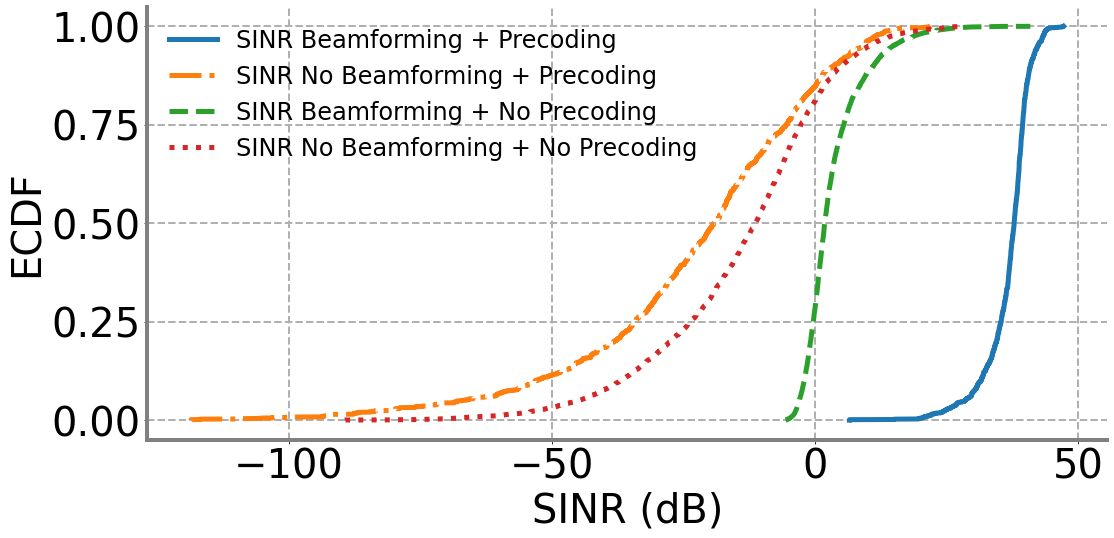

In [81]:
fig, axs = plt.subplots(1,1,figsize=(16,8), gridspec_kw={'width_ratios': [1]})

ecdf1 = ECDF(sinr_bf)
ecdf2 = ECDF(sinr_ori)
ecdf3 = ECDF(sinr_bf_nprecoding)
ecdf4 = ECDF(sinr_ori_nprecoding)

#axs.semilogx(ecdf1.x, ecdf1.y, linestyle='-', linewidth=5)
axs.plot(ecdf1.x, ecdf1.y, linestyle='-', linewidth=5)
axs.plot(ecdf2.x, ecdf2.y, linestyle='-.', linewidth=5)
axs.plot(ecdf3.x, ecdf3.y, linestyle='--', linewidth=5)
axs.plot(ecdf4.x, ecdf4.y, linestyle='dotted', linewidth=5)
#axs.plot(ecdf4.x, ecdf4.y, linestyle=':', linewidth=10)
#axs01].plot(b, new_a, linestyle='-', color = 'sienna', linewidth=8)
axs.grid(True, which="both",ls="--", lw=2)
axs.set(xlabel = 'SINR (dB)', ylabel = 'ECDF')
axs.xaxis.label.set_size(40)
axs.yaxis.label.set_size(40)
axs.tick_params(axis='both', which='major',labelsize=40)
fig.tight_layout()
axs.legend(['SINR Beamforming + Precoding','SINR No Beamforming + Precoding','SINR Beamforming + No Precoding','SINR No Beamforming + No Precoding'],fancybox=False, framealpha=0, edgecolor = 'white',)
#axs.legend(['$0^{\circ}\leq\Delta\phi<30^{\circ}$','$30^{\circ}\leq\Delta\phi<60^{\circ}$','$60^{\circ}\leq\Delta\phi<90^{\circ}$','$90^{\circ}\leq\Delta\phi<120^{\circ}$'], 
#              fancybox=False, framealpha=0, edgecolor = 'white',loc=1, prop={'size':45}, bbox_to_anchor=(1.03, 0.7))

In [12]:
rate_beamformed_nprecoding_dict.keys()

dict_keys([1, 2, 3, 4, 5, 6])

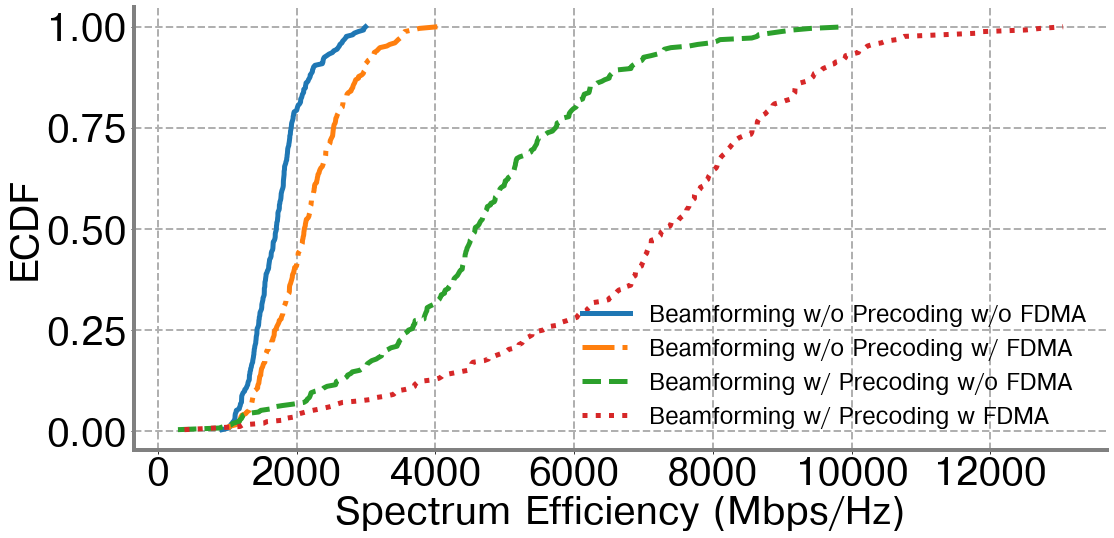

In [18]:
fig, axs = plt.subplots(1,1,figsize=(16,8), gridspec_kw={'width_ratios': [1]})

ecdf1 = ECDF(rate_beamformed_nprecoding_dict[5])
ecdf2 = ECDF(rate_beamformed_FDMA_nprecoding_dict[5])
ecdf3 = ECDF(rate_beamformed_precoding_dict[5])
ecdf4 = ECDF(rate_beamformed_FDMA_precoding_dict[5])

#axs.semilogx(ecdf1.x, ecdf1.y, linestyle='-', linewidth=5)
axs.plot(ecdf1.x/10e6, ecdf1.y, linestyle='-', linewidth=5)
axs.plot(ecdf2.x/10e6, ecdf2.y, linestyle='-.', linewidth=5)
axs.plot(ecdf3.x/10e6, ecdf3.y, linestyle='--', linewidth=5)
axs.plot(ecdf4.x/10e6, ecdf4.y, linestyle='dotted', linewidth=5)
#axs.plot(ecdf4.x, ecdf4.y, linestyle=':', linewidth=10)
#axs01].plot(b, new_a, linestyle='-', color = 'sienna', linewidth=8)
axs.grid(True, which="both",ls="--", lw=2)
axs.set(xlabel = 'Spectrum Efficiency (Mbps/Hz)', ylabel = 'ECDF')
axs.xaxis.label.set_size(40)
axs.yaxis.label.set_size(40)
axs.tick_params(axis='both', which='major',labelsize=40)
fig.tight_layout()
axs.legend(['Beamforming w/o Precoding w/o FDMA','Beamforming w/o Precoding w/ FDMA','Beamforming w/ Precoding w/o FDMA','Beamforming w/ Precoding w FDMA'],fancybox=False, framealpha=0, edgecolor = 'white',)
#axs.legend(['$0^{\circ}\leq\Delta\phi<30^{\circ}$','$30^{\circ}\leq\Delta\phi<60^{\circ}$','$60^{\circ}\leq\Delta\phi<90^{\circ}$','$90^{\circ}\leq\Delta\phi<120^{\circ}$'], 
#              fancybox=False, framealpha=0, edgecolor = 'white',loc=1, prop={'size':45}, bbox_to_anchor=(1.03, 0.7))

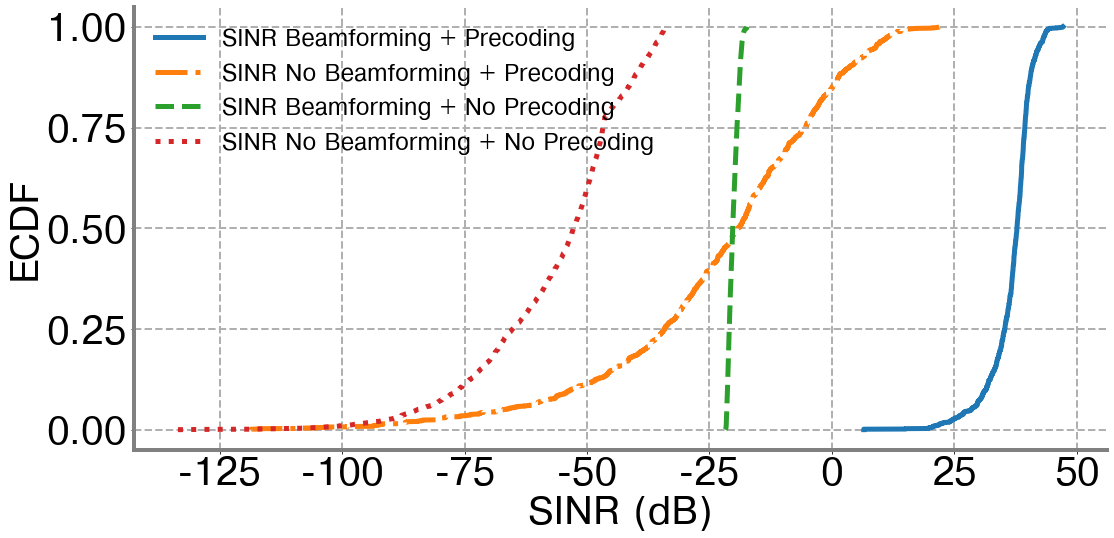

In [93]:
fig, axs = plt.subplots(1,1,figsize=(16,8), gridspec_kw={'width_ratios': [1]})

ecdf1 = ECDF(sinr_bf)
ecdf2 = ECDF(sinr_ori)
ecdf3 = ECDF(sinr_bf_nprecoding)
ecdf4 = ECDF(sinr_ori_nprecoding)

#axs.semilogx(ecdf1.x, ecdf1.y, linestyle='-', linewidth=5)
axs.plot(ecdf1.x, ecdf1.y, linestyle='-', linewidth=5)
axs.plot(ecdf2.x, ecdf2.y, linestyle='-.', linewidth=5)
axs.plot(ecdf3.x, ecdf3.y, linestyle='--', linewidth=5)
axs.plot(ecdf4.x, ecdf4.y, linestyle='dotted', linewidth=5)
#axs.plot(ecdf4.x, ecdf4.y, linestyle=':', linewidth=10)
#axs01].plot(b, new_a, linestyle='-', color = 'sienna', linewidth=8)
axs.grid(True, which="both",ls="--", lw=2)
axs.set(xlabel = 'SINR (dB)', ylabel = 'ECDF')
axs.xaxis.label.set_size(40)
axs.yaxis.label.set_size(40)
axs.tick_params(axis='both', which='major',labelsize=40)
fig.tight_layout()
axs.legend(['SINR Beamforming + Precoding','SINR No Beamforming + Precoding','SINR Beamforming + No Precoding','SINR No Beamforming + No Precoding'],fancybox=False, framealpha=0, edgecolor = 'white',)
#axs.legend(['$0^{\circ}\leq\Delta\phi<30^{\circ}$','$30^{\circ}\leq\Delta\phi<60^{\circ}$','$60^{\circ}\leq\Delta\phi<90^{\circ}$','$90^{\circ}\leq\Delta\phi<120^{\circ}$'], 
#              fancybox=False, framealpha=0, edgecolor = 'white',loc=1, prop={'size':45}, bbox_to_anchor=(1.03, 0.7))